## Pumpkin Varieties and Color

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

Let's look at the relationship between color and variety

In [1]:
import pandas as pd
import numpy as np

full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [4]:
columns_to_select = ['City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Color']
pumpkins = full_pumpkins.loc[:, columns_to_select]
pumpkins.dropna(inplace=True)
pumpkins.head() 

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


In [5]:
pumpkins.info()

<class 'pandas.DataFrame'>
Index: 991 entries, 2 to 1698
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   City Name  991 non-null    str  
 1   Package    991 non-null    str  
 2   Variety    991 non-null    str  
 3   Origin     991 non-null    str  
 4   Item Size  991 non-null    str  
 5   Color      991 non-null    str  
dtypes: str(6)
memory usage: 54.2 KB


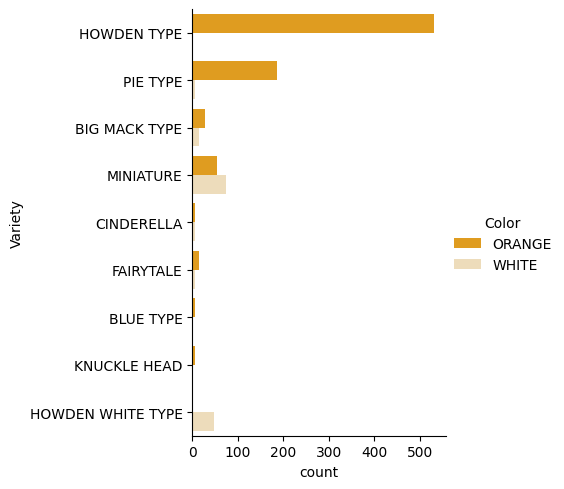

In [6]:
import seaborn as sns

palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}

sns.catplot(
    data=pumpkins,
    y='Variety',
    hue='Color',
    kind='count',
    palette=palette,
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

categorical_features = ['City Name', 'Package', 'Variety', 'Origin']
categorical_encoder = OneHotEncoder(sparse_output=False)

ct = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features),
    ('cat', categorical_encoder, categorical_features),
])

ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(pumpkins)


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_color = label_encoder.fit_transform(pumpkins['Color'])

In [10]:
encoded_pumpkins = encoded_features.assign(Color=encoded_color)

/tmp/ipykernel_14859/2976180893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


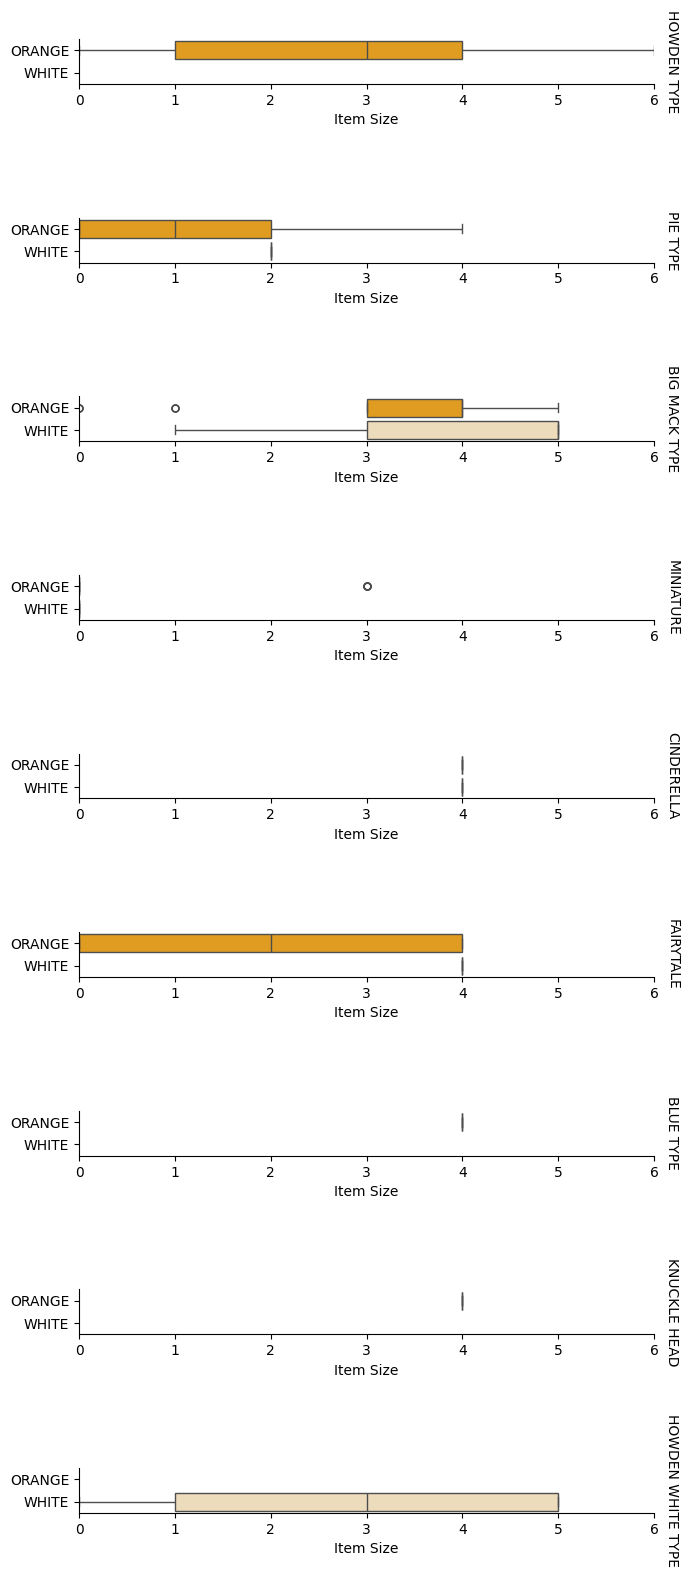

In [11]:
palette = {
    "ORANGE": 'orange',
    "WHITE": 'wheat',
}

pumpkins['Item Size'] = encoded_pumpkins['ord__Item Size']
g = sns.catplot(
    data=pumpkins,
    x='Item Size',
    y='Color',
    row='Variety',
    kind='box',
    orient='h',
    sharex=False,
    margin_titles=True,
    height=1.8,
    aspect=4,
    palette=palette,
)

g.set(xlabel='Item Size', ylabel="").set(xlim=(0,6))
g.set_titles(row_template='{row_name}')

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]
y = encoded_pumpkins['Color']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1 Score: ', f1_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       157
           1       0.83      0.69      0.75        42

    accuracy                           0.90       199
   macro avg       0.87      0.83      0.85       199
weighted avg       0.90      0.90      0.90       199

Predicted labels:  [0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 1 0 1 0 0]
F1 Score:  0.7532467532467533


In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, predictions)

array([[151,   6],
       [ 13,  29]])

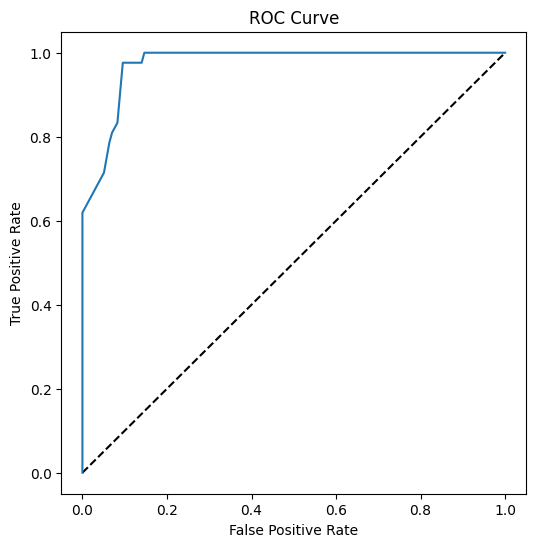

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:, 1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [21]:
auc = roc_auc_score(y_test, y_scores[:, 1])
print('AUC: ', auc)

#To read https://web.stanford.edu/~jurafsky/slp3/5.pdf

AUC:  0.9739156809220504
